In [1]:
# Quick GPU/CUDA sanity check — confirms the conda env has a working PyTorch+CUDA build
# before we burn time on map I/O. Expected: A40, CUDA available True.
import torch
print("Torch version:", torch.__version__)
print("Built with CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.5.1+cu121
Built with CUDA: 12.1
CUDA available: True
GPU: NVIDIA A40


# levelXdata → ContextVAE preprocessing

Converts recordings from **inD / uniD / rounD** into the on-disk format expected by `data.py`.
Reference contracts live in `contextvae-training-pipeline.txt` (§3) and `levelx-dataset-formats.txt`.

Per recording this notebook writes:

- `<train|val>/<dataset>_<recId>.txt` — rows of `fid aid x y heading group`
- `<train|val>/<dataset>_<recId>.info` — `<first_frame_id> <map_name>`
- `map/<dataset>_<recId>.pkl` — `(semantic_map [3,H,W] in [-1,1], H 3x3)`

Pipeline choices (from the thesis plan):
- Frames downsampled 25 Hz → 5 Hz (every 5th frame), then renumbered to start at 0 with Δ=1.
- Vehicles → group `VEHICLE/TARGET`; VRUs → `VRU` (kept as context, not predicted).
- Heading converted from degrees → radians.
- Local-frame `xCenter`, `yCenter` written verbatim (the loader handles ego rotation).
- Map = the `XX_background.png` orthomap, normalized to `[-1, 1]`, with a homography that
  maps local-frame `(x, y)` to image `(row, col)` assuming image top-left = local origin and image-y
  flipped vs +y-up. Verified visually in the sanity-check cell.
- 1e9 neighbor padding is the loader's job, not the preprocessor's — we just emit valid rows.

Configure the training run with `inclusive_groups=["TARGET"]`.
Optional VRU prediction later: add `"VRU"` to `inclusive_groups`.

In [2]:
# Standard library + scientific stack.
# tqdm.auto picks the notebook progress bar when available, plain tqdm otherwise.
import os
import sys
import pickle
import random
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

/home/vdelis/anaconda3/envs/new_xupei_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

Edit `DATA_ROOT` / `DATASET_SUBDIR` to match your local layout. The expected
per-dataset structure is:
```
<DATA_ROOT>/<dataset>/<DATASET_SUBDIR>/<recId>_recordingMeta.csv
<DATA_ROOT>/<dataset>/<DATASET_SUBDIR>/<recId>_tracksMeta.csv
<DATA_ROOT>/<dataset>/<DATASET_SUBDIR>/<recId>_tracks.csv
<DATA_ROOT>/<dataset>/<DATASET_SUBDIR>/<recId>_background.png
```
If the layout differs (e.g. recordings live directly under `<DATA_ROOT>/<dataset>/`),
set `DATASET_SUBDIR = ""`.

In [3]:
# --- Paths ----------------------------------------------------------------
DATA_ROOT      = Path("/home/vdelis/ContextVAE/levelx")               
TARGET_FOLDER  = Path("/home/vdelis/ContextVAE/data/levelx")          # output root consumed by data.py
DATASETS       = ["inD", "uniD", "rounD"]                             # highD excluded: different schema (see levelx-dataset-formats.txt §2)
DATASET_SUBDIR = "data"                                               # directory inside the dataset folder, i.e. ./levelx/inD/data

# --- Frame-rate downsample -------------------------------------------------
# levelXdata records at ~25 Hz; ContextVAE's nuScenes-style configs operate at 5 Hz.
# Keeping every 5th frame matches the thesis plan (L1=10 frames=2 s, H=25 frames=5 s).
INPUT_FRAME_RATE  = 25.0
TARGET_FRAME_RATE = 5.0
FRAMESKIP = int(round(INPUT_FRAME_RATE / TARGET_FRAME_RATE))   # = 5

# --- Split + run options ---------------------------------------------------
VAL_FRACTION = 0.2     # per-dataset val fraction (stratified split below)
SEED         = 0       # for reproducible train/val partition
WRITE_MAPS   = True    # set False for the no-map baseline (skips map/*.pkl)

# Class label sets (lowercased). Verified in the discovery cell.
# "animal" and any future unknown label fall through to DROP.
VEHICLE_CLASSES = {"car", "truck", "truck_bus", "bus", "van", "trailer"}
VRU_CLASSES     = {"pedestrian", "bicycle", "motorcycle"}

# Output directory layout expected by data.Dataloader: train/, val/, map/.
TRAIN_DIR = TARGET_FOLDER / "train"
VAL_DIR   = TARGET_FOLDER / "val"
MAP_DIR   = TARGET_FOLDER / "map"
for p in (TRAIN_DIR, VAL_DIR, MAP_DIR):
    p.mkdir(parents=True, exist_ok=True)

print(f"Output       : {TARGET_FOLDER}")
print(f"Frameskip    : {FRAMESKIP}  ({INPUT_FRAME_RATE} Hz -> {TARGET_FRAME_RATE} Hz)")
print(f"Datasets     : {DATASETS}")
print(f"Write maps   : {WRITE_MAPS}")

Output       : /home/vdelis/ContextVAE/data/levelx
Frameskip    : 5  (25.0 Hz -> 5.0 Hz)
Datasets     : ['inD', 'uniD', 'rounD']
Write maps   : True


## 2. Discover recordings and inspect class labels

Walks `<DATA_ROOT>/<dataset>/<DATASET_SUBDIR>` for `*_tracks.csv` files, then
tallies the unique `class` labels in their `tracksMeta` to confirm `VEHICLE_CLASSES`
and `VRU_CLASSES` cover everything you care about.

In [4]:
def discover_recordings(data_root: Path, datasets: List[str]) -> List[Tuple[str, str, Path]]:
    """Walk each dataset folder and collect (dataset, recording_id, parent_dir) tuples.

    A recording is identified by the presence of an `<recId>_tracks.csv` file;
    the matching tracksMeta / recordingMeta / background files are loaded lazily later.
    """
    out: List[Tuple[str, str, Path]] = []
    for ds in datasets:
        ds_dir = data_root / ds / DATASET_SUBDIR if DATASET_SUBDIR else data_root / ds
        print(ds_dir)
        if not ds_dir.exists():
            print(f"  [skip] {ds_dir} (not found)")
            continue
        for f in sorted(ds_dir.glob("*_tracks.csv")):
            rec = f.name[: -len("_tracks.csv")]   # strip suffix to recover the recording id (e.g. "00")
            # print(f.name)
            out.append((ds, rec, ds_dir))
    return out


recordings = discover_recordings(DATA_ROOT, DATASETS)
print(f"Found {len(recordings)} recordings.")
for ds, rec, _ in recordings[:5]:
    print(f"  {ds}/{rec}")
if len(recordings) > 5:
    print(f"  ... +{len(recordings) - 5} more")

# Tally unique class labels across every recording so we can confirm
# VEHICLE_CLASSES / VRU_CLASSES above cover them. Any label hitting "DROP"
# is a candidate for re-bucketing (e.g. "animal" is rare and intentionally dropped).
class_counts: Dict[str, int] = {}
for ds, rec, rec_dir in recordings:
    tm = pd.read_csv(rec_dir / f"{rec}_tracksMeta.csv")
    for c in tm["class"]:
        k = str(c).strip().lower()
        class_counts[k] = class_counts.get(k, 0) + 1

print("\nUnique class labels (n_tracks  bucket):")
for c, n in sorted(class_counts.items(), key=lambda x: -x[1]):
    bucket = "VEHICLE" if c in VEHICLE_CLASSES else ("VRU" if c in VRU_CLASSES else "DROP")
    print(f"  {c:<20s} {n:>6d}  {bucket}")

/home/vdelis/ContextVAE/levelx/inD/data
/home/vdelis/ContextVAE/levelx/uniD/data
/home/vdelis/ContextVAE/levelx/rounD/data
Found 70 recordings.
  inD/00
  inD/01
  inD/02
  inD/03
  inD/04
  ... +65 more

Unique class labels (n_tracks  bucket):
  car                   20654  VEHICLE
  pedestrian            10984  VRU
  bicycle                3058  VRU
  truck                  1099  VEHICLE
  van                     671  VEHICLE
  truck_bus               357  VEHICLE
  trailer                 260  VEHICLE
  motorcycle              160  VRU
  bus                      81  VEHICLE
  animal                    3  DROP


## 3. Per-recording loaders + helpers

In [10]:
def load_recording(rec_dir: Path, rec_id: str) -> Tuple[dict, pd.DataFrame, pd.DataFrame]:
    """Load the three CSVs that fully describe a single levelXdata recording.

    Returns:
        rec_meta    : dict with frameRate, orthoPxToMeter, locationId, ... (single row).
        tracks_meta : per-track summary (one row per agent — class, lifetime, dims).
        tracks      : per-frame trajectory rows (the bulk data).
    """
    rec_meta    = pd.read_csv(rec_dir / f"{rec_id}_recordingMeta.csv").iloc[0].to_dict()
    tracks_meta = pd.read_csv(rec_dir / f"{rec_id}_tracksMeta.csv")
    tracks      = pd.read_csv(rec_dir / f"{rec_id}_tracks.csv")
    return rec_meta, tracks_meta, tracks


def class_to_group(cls: str) -> Optional[str]:
    """Map raw class label to a ContextVAE group string. Unknown classes are dropped.

    "VEHICLE/TARGET" is a slash-separated tag list; the loader treats any agent
    whose group contains an entry from `inclusive_groups` as a prediction target.
    Tagging vehicles as both VEHICLE and TARGET lets us flip VRUs into targets
    later by adding "VRU" to inclusive_groups, without re-running preprocessing.
    """
    c = str(cls).strip().lower()
    if c in VEHICLE_CLASSES:
        return "VEHICLE/TARGET"
    if c in VRU_CLASSES:
        return "VRU"
    return None

## 4. Trajectory writer

Emits one row per `(retained frame, agent)` after frameskip + class filtering.
Frame ids are renumbered to a uniform `0, 1, 2, …` grid so the loader's
constant-Δt check is trivially satisfied.

In [11]:
def build_trajectory_lines(
    tracks_meta: pd.DataFrame,
    tracks: pd.DataFrame,
    frameskip: int,
) -> Tuple[List[str], int]:
    """Convert one recording's tracks.csv into ContextVAE-format rows.

    Output rows:  ``fid aid x y heading group``  (whitespace-separated)
    Frame ids are renumbered to a uniform 0,1,2,... grid so the loader's
    constant-Δt check passes trivially after frameskip.
    """
    # Look up class per trackId (avoids a join on the big tracks DataFrame).
    cls_by_tid = dict(zip(tracks_meta["trackId"], tracks_meta["class"]))

    # Keep every Nth frame (25 Hz -> 5 Hz when frameskip=5).
    df = tracks[tracks["frame"] % frameskip == 0].copy()
    if df.empty:
        return [], 0

    # Renumber frames to 0,1,2,... so Δt = 1 in the output.
    min_f = int(df["frame"].min())
    df["fid"] = ((df["frame"] - min_f) // frameskip).astype(int)

    # Drop tracks shorter than 2 retained frames — the loader strips them anyway,
    # and removing them here also avoids a finite-difference NaN on velocity.
    counts = df.groupby("trackId").size()
    df = df[df["trackId"].isin(counts[counts >= 2].index)].copy()

    # Tag each row with its group string; rows mapping to None (unknown class) are dropped.
    df["group"] = df["trackId"].map(lambda t: class_to_group(cls_by_tid.get(t, "")))
    df = df[df["group"].notnull()].copy()
    if df.empty:
        return [], 0

    # Stable sort so the .txt is grouped by frame then track — easier to diff/inspect.
    df = df.sort_values(["fid", "trackId"], kind="mergesort").reset_index(drop=True)
    fids   = df["fid"].to_numpy()
    tids   = df["trackId"].to_numpy()
    xs     = df["xCenter"].to_numpy(dtype=np.float64)
    ys     = df["yCenter"].to_numpy(dtype=np.float64)
    # heading is in degrees in the levelXdata CSVs; ContextVAE expects radians.
    head   = np.deg2rad(df["heading"].to_numpy(dtype=np.float64))
    groups = df["group"].to_numpy()

    # Fixed-width formatting keeps files diffable (matches the reference scripts' style).
    lines = [
        "{:<6d} {:<6d} {:10.4f} {:10.4f} {:8.4f} {}".format(
            int(fid), int(tid), float(x), float(y), float(h), g
        )
        for fid, tid, x, y, h, g in zip(fids, tids, xs, ys, head, groups)
    ]
    # second tuple element is first_frame; we always renumber to start at 0.
    return lines, 0


def write_recording_txt_info(
    out_dir: Path, name: str, lines: List[str], first_frame: int, map_name: str
) -> None:
    """Write the .txt (trajectory rows) and .info (`<first_frame> <map_name>`) pair."""
    (out_dir / f"{name}.txt").write_text("\n".join(lines))
    (out_dir / f"{name}.info").write_text(f"{first_frame} {map_name}")

## 5. Map pickle writer

We use the per-recording aerial orthomap (`<rec>_background.png`) as the 3-channel
map input — substituting the rasterized HD-map channels nuScenes/Lyft/Waymo use.
Channel order is the image's native RGB; values are normalized to `[-1, 1]`.

The homography `H` follows the convention in `contextvae-training-pipeline.txt` §3.3.
It maps a world point `(x, y, 1)` to the image pixel `(row, col, 1)` under the assumption
that the image's top-left corresponds to local-frame origin `(0, 0)`, image-x grows
with `+local_x`, and image-y grows with `-local_y`. Verify per location with
the visualization cell below — if trajectories don't land on the road, the offset
is wrong and needs a per-recording correction term.

In [12]:
def build_map_pickle(rec_dir: Path, rec_id: str, rec_meta: dict) -> Tuple[np.ndarray, np.ndarray]:
    """Build the (semantic_map, H) pickle payload from the recording's orthoimage.

    semantic_map : float32 (3, H, W) in [-1, 1] — RGB orthomap normalized to the
                   range data.Dataloader's map encoder expects.
    H            : 3x3 homography mapping local-frame (x, y, 1) -> image (row, col, 1).
                   Convention follows contextvae-training-pipeline.txt §3.3.
    """
    # Load the per-recording aerial orthomap (XX_background.png) and normalize to [-1, 1].
    img_path = rec_dir / f"{rec_id}_background.png"
    img = np.asarray(Image.open(img_path).convert("RGB")).astype(np.float32) / 255.0
    img = (img * 2.0 - 1.0).clip(-1.0, 1.0)
    semantic_map = np.ascontiguousarray(img.transpose(2, 0, 1))   # HWC -> CHW (3, H, W)

    # orthoPxToMeter is meters-per-pixel; map_scale is its inverse (pixels-per-meter).
    ortho_px_to_meter = float(rec_meta["orthoPxToMeter"])
    map_scale = 1.0 / ortho_px_to_meter

    # Map dimensions in meters (used to construct the H translation terms).
    H_img, W_img = semantic_map.shape[1], semantic_map.shape[2]
    w_m = W_img / map_scale
    h_m = H_img / map_scale
    # Map "center" in local-frame coords. Assumes image top-left == local origin (0, 0)
    # and image-y is flipped vs +y-up. Verify visually with the sanity-check cell;
    # if trajectories miss the road, the offset assumption needs a per-recording correction.
    x_c =  0.5 * w_m
    y_c = -0.5 * h_m
    # Row-major homography: (x, y, 1) -> (row, col, 1).
    # Row index grows with -y (image-y down), col index grows with +x.
    H = np.array([
        [0.,         -map_scale,  (y_c + 0.5 * h_m) * map_scale],
        [map_scale,   0.,        -(x_c - 0.5 * w_m) * map_scale],
        [0.,          0.,          1.],
    ], dtype=np.float64)
    return semantic_map, H


def write_map_pickle(map_dir: Path, name: str, semantic_map: np.ndarray, H: np.ndarray) -> None:
    """Pickle (semantic_map, H) under `<map_dir>/<name>.pkl` — the format Dataloader expects."""
    with open(map_dir / f"{name}.pkl", "wb") as f:
        pickle.dump((semantic_map, H), f)

## 6. Train / val split

Split is per-recording, stratified by dataset (so each dataset contributes
validation recordings). Set the seed for reproducibility.

In [13]:
def split_train_val(
    recordings: List[Tuple[str, str, Path]],
    val_fraction: float,
    seed: int,
) -> Dict[str, str]:
    """Per-recording split, stratified by dataset so each of inD/uniD/rounD
    contributes at least one validation recording.

    Returns: dict mapping "<dataset>_<recId>" -> "train" | "val".
    """
    # Bucket recordings by dataset.
    by_ds: Dict[str, List[Tuple[str, str, Path]]] = {}
    for r in recordings:
        by_ds.setdefault(r[0], []).append(r)
    rng = random.Random(seed)   # local RNG so the split doesn't depend on global state
    out: Dict[str, str] = {}
    for ds, recs in by_ds.items():
        recs_sorted = sorted(recs, key=lambda r: r[1])   # deterministic order before sampling
        n_val = max(1, int(round(len(recs_sorted) * val_fraction)))
        val_idx = set(rng.sample(range(len(recs_sorted)), n_val))
        for i, (_, rec, _) in enumerate(recs_sorted):
            out[f"{ds}_{rec}"] = "val" if i in val_idx else "train"
    return out


splits = split_train_val(recordings, VAL_FRACTION, SEED)
n_train = sum(1 for v in splits.values() if v == "train")
n_val   = sum(1 for v in splits.values() if v == "val")
print(f"Train: {n_train} recordings | Val: {n_val} recordings")
# Per-dataset breakdown — useful to confirm stratification did the right thing.
for ds in DATASETS:
    n_t = sum(1 for k, v in splits.items() if k.startswith(ds + "_") and v == "train")
    n_v = sum(1 for k, v in splits.items() if k.startswith(ds + "_") and v == "val")
    print(f"  {ds:<6s}  train={n_t}  val={n_v}")

Train: 55 recordings | Val: 15 recordings
  inD     train=26  val=7
  uniD    train=10  val=3
  rounD   train=19  val=5


## 7. Run preprocessing

Sequential loop with a progress bar. ~30–40 recordings total — takes a few minutes
on this hardware. Map writing dominates the time budget; set `WRITE_MAPS=False`
if you only want the no-map baseline.

In [9]:
# Sequential per-recording loop. Map writing dominates wall-clock time;
# the overall job is a few minutes on this hardware.
errors: List[Tuple[str, str]] = []
n_targets_total = 0   # sanity counter — total VEHICLE/TARGET rows emitted
for ds, rec, rec_dir in tqdm(recordings, desc="recordings"):
    name = f"{ds}_{rec}"   # globally unique scene id used by both .txt/.info and .pkl
    # print(name)
    out_dir = TRAIN_DIR if splits[name] == "train" else VAL_DIR
    try:
        rec_meta, tracks_meta, tracks = load_recording(rec_dir, rec)
        lines, first_frame = build_trajectory_lines(tracks_meta, tracks, FRAMESKIP)
        if not lines:
            # Nothing usable after frameskip + class filter — record and move on.
            errors.append((name, "no usable agents after filtering"))
            continue
        write_recording_txt_info(out_dir, name, lines, first_frame, name)
        n_targets_total += sum(1 for ln in lines if "TARGET" in ln)
        if WRITE_MAPS:
            sm, H = build_map_pickle(rec_dir, rec, rec_meta)
            write_map_pickle(MAP_DIR, name, sm, H)
    except Exception as e:
        # Capture rather than abort — one bad recording shouldn't kill the whole batch.
        errors.append((name, repr(e)))

print(f"\nDone. {len(recordings) - len(errors)} ok, {len(errors)} failed.")
print(f"Total VEHICLE/TARGET rows written: {n_targets_total}")
for name, err in errors[:10]:
    print(f"  [fail] {name}: {err}")

recordings: 100%|██████████| 70/70 [00:56<00:00,  1.23it/s]


Done. 70 ok, 0 failed.
Total VEHICLE/TARGET rows written: 3438558


## 8. Sanity check — visualize trajectories on the orthomap

Load a written `.txt` and overlay vehicle trajectories on the orthomap pickle
via the homography `H`. If trajectories don't track the road geometry, the
image-origin assumption is wrong for that location.

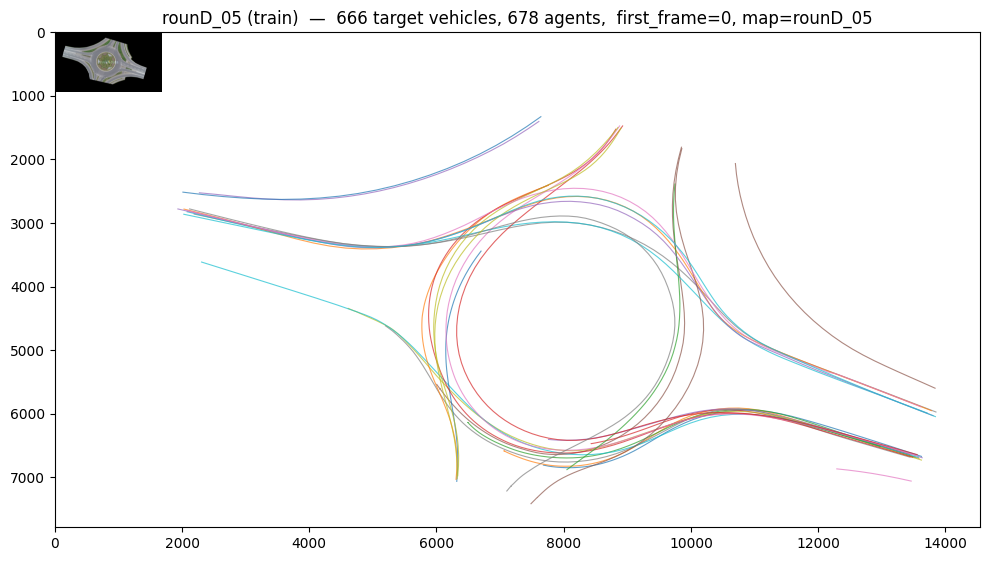

In [5]:
def sanity_visualize(scene_name: str, split: str = "train", max_targets: int = 30) -> None:
    """Overlay TARGET trajectories on the orthomap to visually verify the homography.

    If trajectories don't track the road geometry, the (x_c, y_c) offset assumption
    in build_map_pickle is wrong for that location and needs a per-recording correction.
    """
    base = (TRAIN_DIR if split == "train" else VAL_DIR) / scene_name
    # Load the .txt we just wrote (whitespace-separated).
    df = pd.read_csv(
        base.with_suffix(".txt"),
        sep=r"\s+", header=None,
        names=["fid", "aid", "x", "y", "heading", "group"],
    )
    info = base.with_suffix(".info").read_text().strip().split()
    first_frame, map_name = int(info[0]), info[1]

    fig, ax = plt.subplots(figsize=(10, 10))
    map_pkl = MAP_DIR / f"{map_name}.pkl"
    if map_pkl.exists():
        # Mapped variant: project (x, y) -> (row, col) via H and overlay on the orthomap.
        with open(map_pkl, "rb") as f:
            semantic_map, H = pickle.load(f)
        img = (semantic_map.transpose(1, 2, 0) + 1.0) / 2.0   # CHW -> HWC, [-1,1] -> [0,1]
        ax.imshow(img.clip(0, 1))
        targets = df[df["group"].str.contains("TARGET")]
        for tid, g in list(targets.groupby("aid"))[:max_targets]:
            xy = g[["x", "y"]].to_numpy()
            ones = np.ones((xy.shape[0], 1))
            rc = (np.hstack([xy, ones]) @ H.T)[:, :2]   # (row, col) in image pixels
            # imshow uses (col, row) as (x, y), so swap when plotting.
            ax.plot(rc[:, 1], rc[:, 0], "-", lw=0.8, alpha=0.7)
    else:
        # No-map fallback: plot in metric local frame.
        ax.set_aspect("equal")
        for tid, g in list(df[df["group"].str.contains("TARGET")].groupby("aid"))[:max_targets]:
            ax.plot(g["x"], g["y"], "-", lw=0.8, alpha=0.7)
        ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")

    n_targets = df[df["group"].str.contains("TARGET")]["aid"].nunique()
    n_total   = df["aid"].nunique()
    ax.set_title(
        f"{scene_name} ({split})  —  {n_targets} target vehicles, {n_total} agents,  "
        f"first_frame={first_frame}, map={map_name}"
    )
    plt.tight_layout()
    plt.show()


written = sorted(p.stem for p in TRAIN_DIR.glob("*.txt"))
if written:
    # Pick an arbitrary scene (index 30) for a single visual check.
    sanity_visualize(written[30], "train")
    # If i want to see more images:
    # for i in range(0,n_train):
    #     sanity_visualize(written[i], "train")
else:
    print("No files written — check the discovery and main loop.")

## 9. Smoke test — build a real `Dataloader` and pull a sample

Wires the written files into the codebase's loader to verify the contract:
tensor shapes, neighbor padding sentinel, optional map crop. Uses
`ob_horizon=10`, `pred_horizon=25`, `ob_radius=30` per the thesis plan.
If this cell errors, the format is wrong; fix it before training.

In [6]:
# Smoke test — wire the written files into data.Dataloader and pull one sample.
# If this errors, the on-disk format is wrong; fix it before launching a full training run.

# Pin BLAS threads to 1 so the Dataloader's internal ProcessPoolExecutor doesn't
# fight numpy/MKL for the same cores.
import os
import torch
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
print("torch threads:", torch.get_num_threads())

# Make the repo importable, then cap torch threads (this also caps the Dataloader's
# ProcessPoolExecutor at 1 worker — see data.py:107).
sys.path.insert(0, str(Path("/home/vdelis/ContextVAE")))
import torch
torch.set_num_threads(1)
from contextvae.data import Dataloader   # noqa: E402

# Bisect with a single .txt — fastest way to surface a format bug.
one = sorted(TRAIN_DIR.glob("*.txt"))[0]

# Horizons / radius match the thesis plan: 2 s observation, 5 s prediction, 30 m radius.
dl = Dataloader(
    files=[str(one)],           # files=[str(one)], if one used standard files=[str(TRAIN_DIR)]
    ob_horizon=10,
    pred_horizon=25,
    ob_radius=30,
    inclusive_groups=["TARGET"],   # only VEHICLE/TARGET agents become prediction targets
    batch_size=4,
    map_dir=str(MAP_DIR) if WRITE_MAPS else None,
    map_size=224,
    map_scale=1,
)
print(f"Dataloader length: {len(dl)} samples")

# Pull one sample and report shape/dtype of every tensor in the tuple.
item = dl[0]
print(f"Sample is a tuple of length {len(item)}")
for i, t in enumerate(item):
    if hasattr(t, "shape"):
        print(f"  [{i}] tensor shape={tuple(t.shape)} dtype={t.dtype}")
    else:
        print(f"  [{i}] {type(t).__name__}={t}")

# Critical contract: absent neighbor slots are padded with 1e9 (NOT 0).
# Zero-padding would slip past the radius mask and poison attention.
neighbor = next((t for t in item if hasattr(t, "shape") and getattr(t, "ndim", None) == 4), None)
if neighbor is not None:
    nmax = float(neighbor.max())
    print(f"\n  neighbor max = {nmax:g}  (>=1e9 expected wherever slots are padded)")
    assert nmax >= 1e9 or neighbor.size == 0, "neighbor padding sentinel missing"
print("OK")

torch threads: 16
 Scanning files...
 70 map files founded.
 Loading data files...0/1

 Loading data files...1/1 
   16657 trajectories loaded.
 Loading map files...1/1
Dataloader length: 16657 samples
Sample is a tuple of length 6
  [0] tensor shape=(10, 6) dtype=float32
  [1] tensor shape=(25, 2) dtype=float32
  [2] tensor shape=(35, 4, 6) dtype=float32
  [3] tensor shape=(3, 0, 0) dtype=torch.float32
  [4] tensor shape=(2, 3) dtype=torch.float32
  [5] NoneType=None
OK


## 10. Load the full dataset (train + val)

Same `Dataloader` class, pointed at both split directories. With `torch.set_num_threads(1)`
still in effect from the smoke-test cell, file scanning runs single-process and won't OOM.
Wrap the resulting `Dataloader` in a `torch.utils.data.DataLoader` (using its `batch_sampler`
and `collate_fn`) to iterate full batches — the same pattern `main.py` uses.

In [ ]:
# # Build one Dataloader covering BOTH splits. Pass two paths in `files=`;
# # data.py walks each and concatenates the results.
# full_ds = Dataloader(
#     files=[str(TRAIN_DIR), str(VAL_DIR)],
#     ob_horizon=10,
#     pred_horizon=25,
#     ob_radius=30,
#     inclusive_groups=["TARGET"],
#     batch_size=128,
#     map_dir=str(MAP_DIR) if WRITE_MAPS else None,
#     map_size=224,
#     map_scale=1,
# )
# print(f"Full dataset: {len(full_ds)} trajectory samples")

# # Wrap in a torch DataLoader for batched iteration (same wiring as main.py:92-94).
# full_loader = torch.utils.data.DataLoader(
#     full_ds,
#     batch_sampler=full_ds.batch_sampler,
#     collate_fn=full_ds.collate_fn,
# )
# print(f"Batches per epoch: {full_ds.batches_per_epoch}")

# # Sanity: pull one batch and report tensor shapes.
# batch = next(iter(full_loader))
# labels = ["x", "y", "neighbor", "map", "seq_len"]
# for name, t in zip(labels, batch):
#     if hasattr(t, "shape"):
#         print(f"  {name:<8s} shape={tuple(t.shape)} dtype={t.dtype} device={t.device}")
#     else:
#         print(f"  {name:<8s} {type(t).__name__}={t}")

# # To iterate the full epoch:
# #   for batch in full_loader: ...
# #
# # To keep train and val separable instead of merged, build two Dataloaders:
# #   train_ds = Dataloader(files=[str(TRAIN_DIR)], ...)
# #   val_ds   = Dataloader(files=[str(VAL_DIR)],   ...)

 Scanning files...
 70 map files founded.
 Loading data files...16/70